# Hom-PGD: Polytope Geometry and Gauge Mapping

This tutorial introduces the geometry used by Hom-PGD on a two-dimensional convex polytope. It constructs one explicit problem instance, obtains its reference solution through the shared convex-solver path, and visualizes the gauge map between the latent unit ball and the feasible set.

**Audience.** Readers familiar with constrained optimization, gradients, and basic NumPy/PyTorch.

**Prerequisites.** Install HomOPT in editable mode and start Jupyter from the repository root with `jupyter lab tutorials/hom_pgd`.

**Learning goals.** By the end, you can: 

1. construct the shared 2D polytope toy context;
2. obtain and evaluate the exact-reference solution;
3. map points and rays between the latent ball and the feasible polytope; and
4. interpret the gauge-map round-trip used before Hom-PGD optimization.

## 1. Explicit tutorial configuration

All choices affecting the generated problem, reference solution, or figures are collected here. This is a convex polytope, so the reference uses `ConvexSolver`; the plotting label follows the project convention and is `MOSEK`. The nonconvex star tutorials use IPOPT instead.

In [11]:
from __future__ import annotations

from pathlib import Path

WORKING_DIR = Path.cwd().resolve()
REPO_ROOT = WORKING_DIR if (WORKING_DIR / 'src' / 'homopt').is_dir() else WORKING_DIR.parents[1]
if not (REPO_ROOT / 'src' / 'homopt').is_dir():
    raise RuntimeError('Launch from the repository root or execute this notebook from tutorials/hom_pgd.')

TUTORIAL_CONFIG = {
    'seed': 2030,
    'device': 'cpu',
    'dtype': 'float32',
    'problem_type': 'poly',
    'hom_p_norm': 2,
    'poly_config': {
        'obj': 'quad',
        'n_var': 2,
        'n_linear_cons': 5,
        'n_soc_cons': 0,
        'n_qua_cons': 0,
        'x_lower': -2.0,
        'x_upper': 2.0,
        'margin_scale': 0.75,
        'anchor_interior_ratio': 0.15,
    },
    'reference_solver': 'convex',
    'reference_label': 'MOSEK',
    'x_grid_size': 360,
    'z_grid_size': 220,
    'figure_dir': REPO_ROOT / 'results' / 'figs' / 'tutorials' / 'hom_pgd' / '01_poly_gauge_geometry',
}
# Keep each displayed panel at the same physical size in Jupyter and PDF output.
TUTORIAL_FIGURE_STYLE = {
    'panel_width': 5.6,
    'panel_height': 5.0,
    'single_panel': (5.6, 5.0),
    'two_panel': (11.2, 5.0),
}
TUTORIAL_CONFIG


{'seed': 2030,
 'device': 'cpu',
 'dtype': 'float32',
 'problem_type': 'poly',
 'hom_p_norm': 2,
 'poly_config': {'obj': 'quad',
  'n_var': 2,
  'n_linear_cons': 5,
  'n_soc_cons': 0,
  'n_qua_cons': 0,
  'x_lower': -2.0,
  'x_upper': 2.0,
  'margin_scale': 0.75,
  'anchor_interior_ratio': 0.15},
 'reference_solver': 'convex',
 'reference_label': 'MOSEK',
 'x_grid_size': 360,
 'z_grid_size': 220,
 'figure_dir': PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/01_poly_gauge_geometry')}

## 2. Build the problem and solve the reference

The notebook calls the same construction and reference functions used by the runnable toy benchmark. There is no notebook-specific problem reconstruction and no grid-search fallback.

In [12]:
import numpy as np
import torch

from homopt.experiments.hom_pgd import (
    build_poly_star_toy_context,
    solve_poly_star_toy_reference,
)
from homopt.viz import PAPER_STYLE, apply_paper_style_rcparams
from homopt.viz.artifacts import save_figure
from homopt.viz.landscapes import convex_landscape_grid, convex_z_landscape_grid
from homopt.viz.primitives import draw_convex_landscape, draw_convex_z_landscape

apply_paper_style_rcparams()
problem, hom_map = build_poly_star_toy_context(
    problem_type=TUTORIAL_CONFIG['problem_type'],
    poly_config=TUTORIAL_CONFIG['poly_config'],
    seed=TUTORIAL_CONFIG['seed'],
    device=TUTORIAL_CONFIG['device'],
    dtype=TUTORIAL_CONFIG['dtype'],
    hom_p_norm=TUTORIAL_CONFIG['hom_p_norm'],
)
reference = solve_poly_star_toy_reference(
    TUTORIAL_CONFIG['problem_type'],
    problem,
    reference_solver=TUTORIAL_CONFIG['reference_solver'],
    reference_label=TUTORIAL_CONFIG['reference_label'],
)

x_reference = np.asarray(reference['solution'], dtype=float).reshape(2)
{
    'reference_label': reference['label'],
    'reference_status': reference['status'],
    'reference_objective': float(reference['objective']),
    'reference_violation': float(reference['violation']),
    'gauge_center': hom_map.center.detach().cpu().numpy().reshape(2),
}


{'reference_label': 'MOSEK',
 'reference_status': 'optimal',
 'reference_objective': -0.07335603517580802,
 'reference_violation': 0.0,
 'gauge_center': array([-0.6119047, -1.0689194], dtype=float32)}

## 3. Original and latent geometry

The left panel is the original constrained space. The right panel evaluates the same objective after mapping latent points through the gauge map. The unit disk in latent space is therefore mapped into the feasible polytope.

PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/01_poly_gauge_geometry/original_and_latent_geometry.pdf')

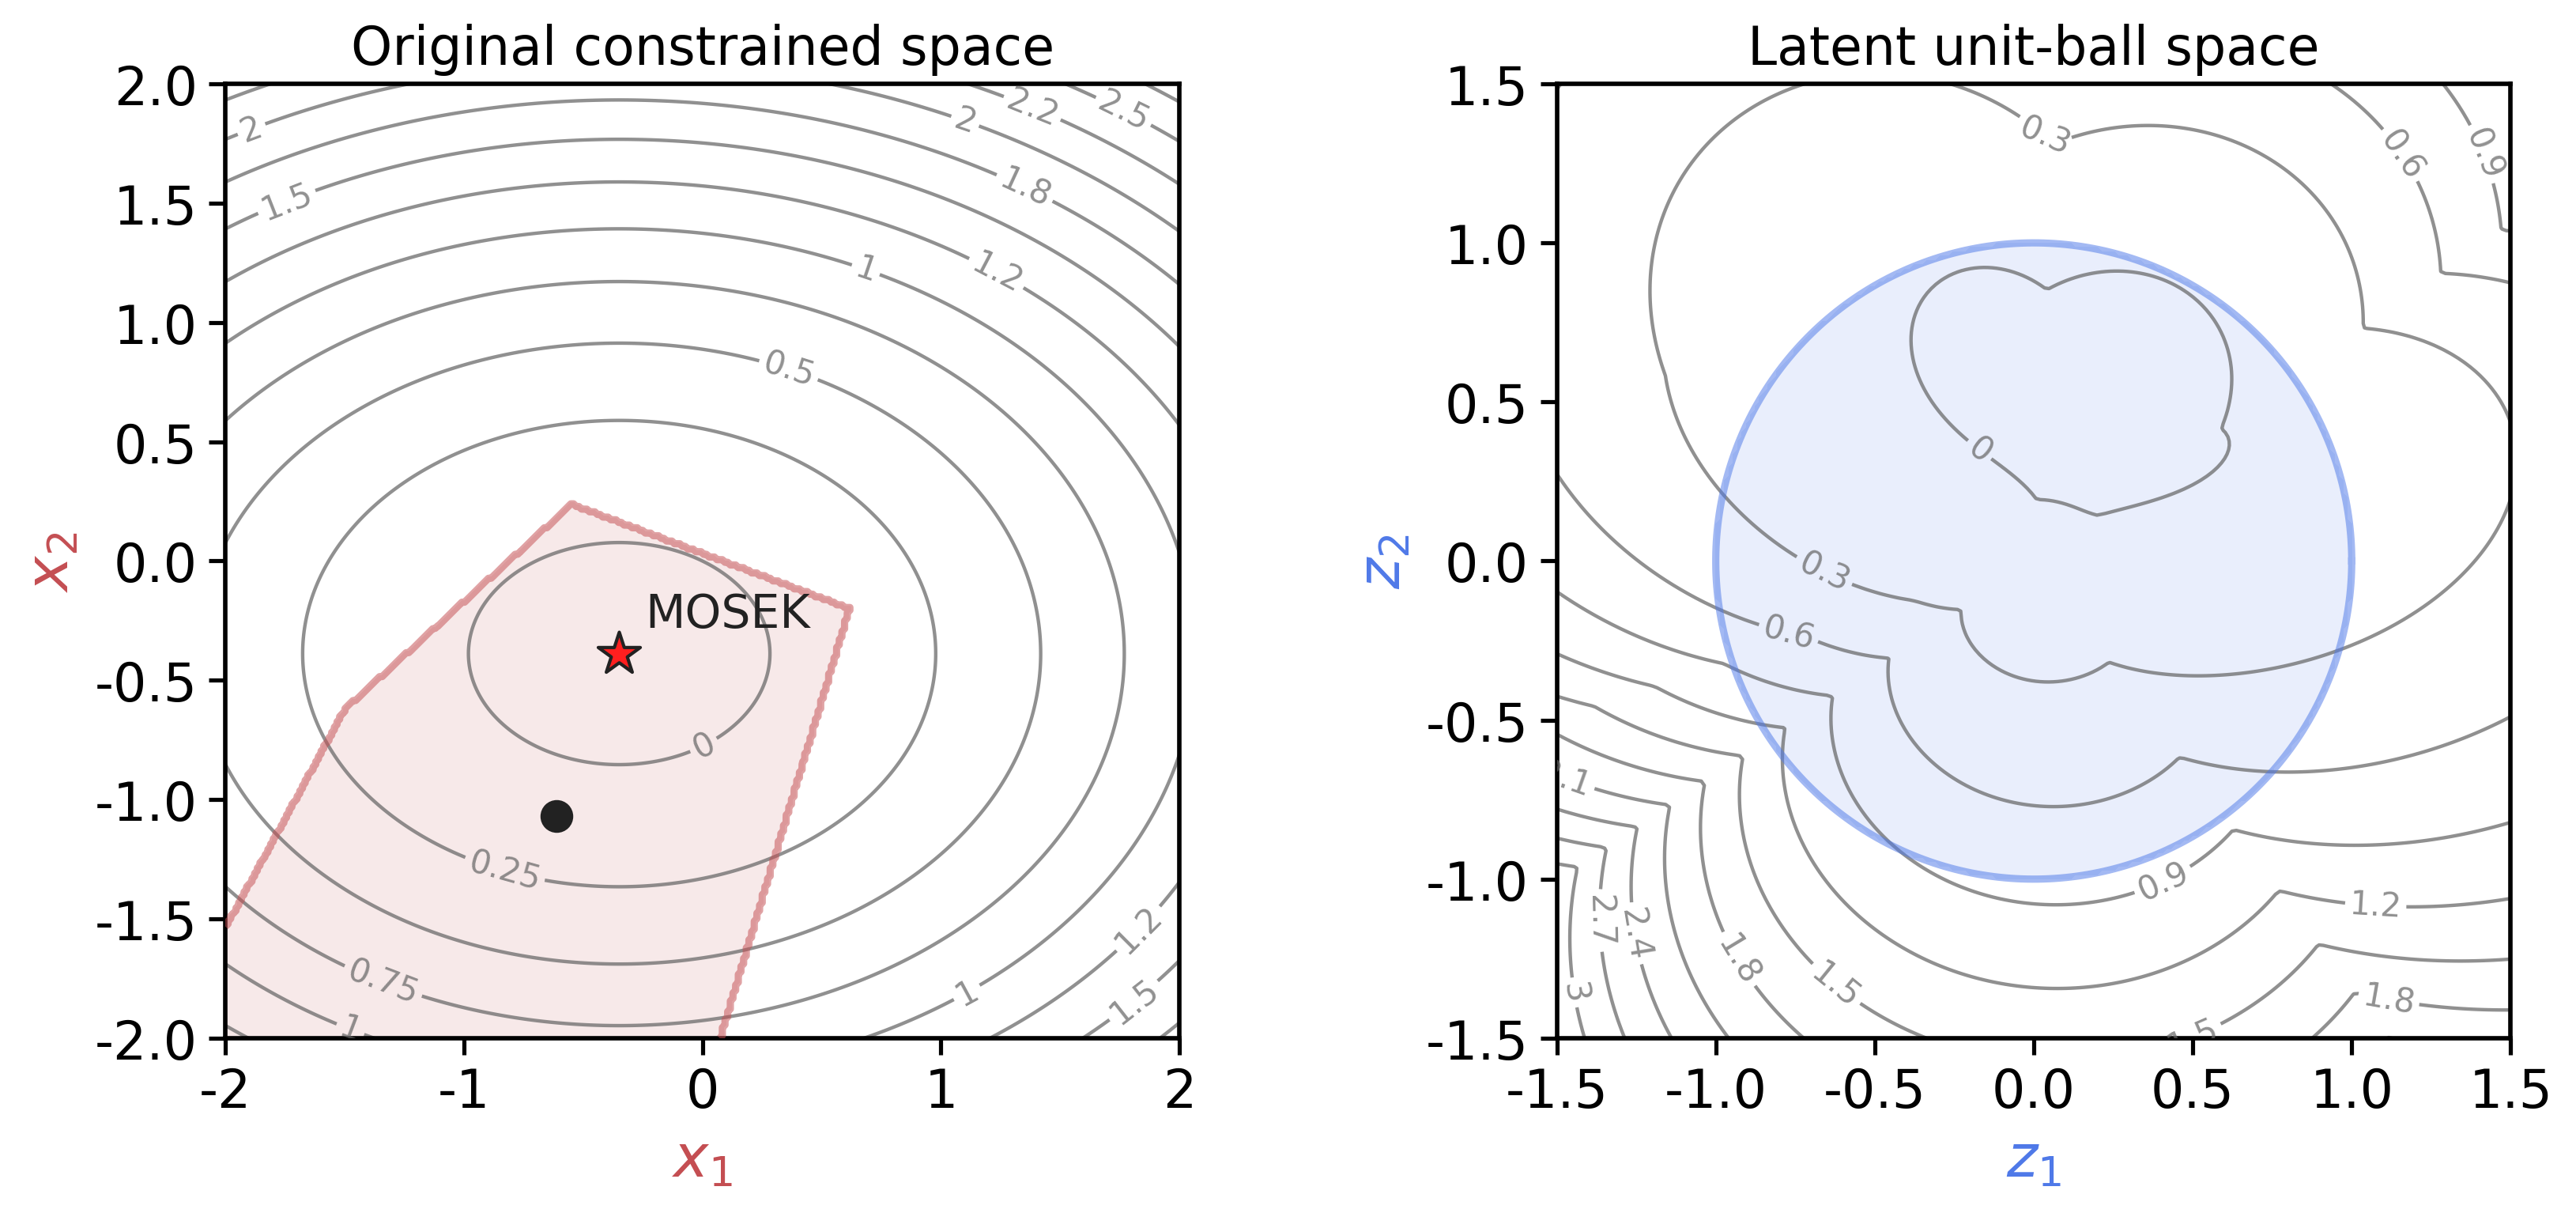

In [13]:
import matplotlib.pyplot as plt

x_low = np.full(2, TUTORIAL_CONFIG['poly_config']['x_lower'], dtype=float)
x_high = np.full(2, TUTORIAL_CONFIG['poly_config']['x_upper'], dtype=float)
X, Y, objective, inequality, equality, eq_resid = convex_landscape_grid(
    problem, x_low, x_high, grid_size=TUTORIAL_CONFIG['x_grid_size']
)
Z1, Z2, z_objective, z_eq_resid, inside, p_norm = convex_z_landscape_grid(
    problem, hom_map, grid_size=TUTORIAL_CONFIG['z_grid_size']
)

fig, (ax_x, ax_z) = plt.subplots(1, 2, figsize=TUTORIAL_FIGURE_STYLE['two_panel'], constrained_layout=True)
draw_convex_landscape(ax_x, X, Y, objective, inequality, equality, eq_resid)
draw_convex_z_landscape(ax_z, Z1, Z2, z_objective, z_eq_resid, inside, p_norm)

for ax, title in ((ax_x, 'Original constrained space'), (ax_z, 'Latent unit-ball space')):
    ax.set_title(title)

ax_x.scatter(*hom_map.center.detach().cpu().numpy().reshape(2), s=80, color='#222222', marker='o', zorder=6)
ax_x.scatter(*x_reference, s=180, color='#FF1F1F', marker='*', edgecolor='#222222', linewidth=1.0, zorder=7)
ax_x.annotate(reference['label'], xy=x_reference, xytext=(8, 8), textcoords='offset points', color='#222222')

geometry_path = save_figure(fig, TUTORIAL_CONFIG['figure_dir'] / 'original_and_latent_geometry.pdf')
geometry_path


## 4. Gauge map on rays

For each direction, a point on the latent unit-circle boundary maps to the corresponding boundary point of the polytope. Points with radius below one stay inside the feasible set.

PosixPath('/Users/lem/Projects/HomOPT/results/figs/tutorials/hom_pgd/01_poly_gauge_geometry/gauge_mapped_rays.pdf')

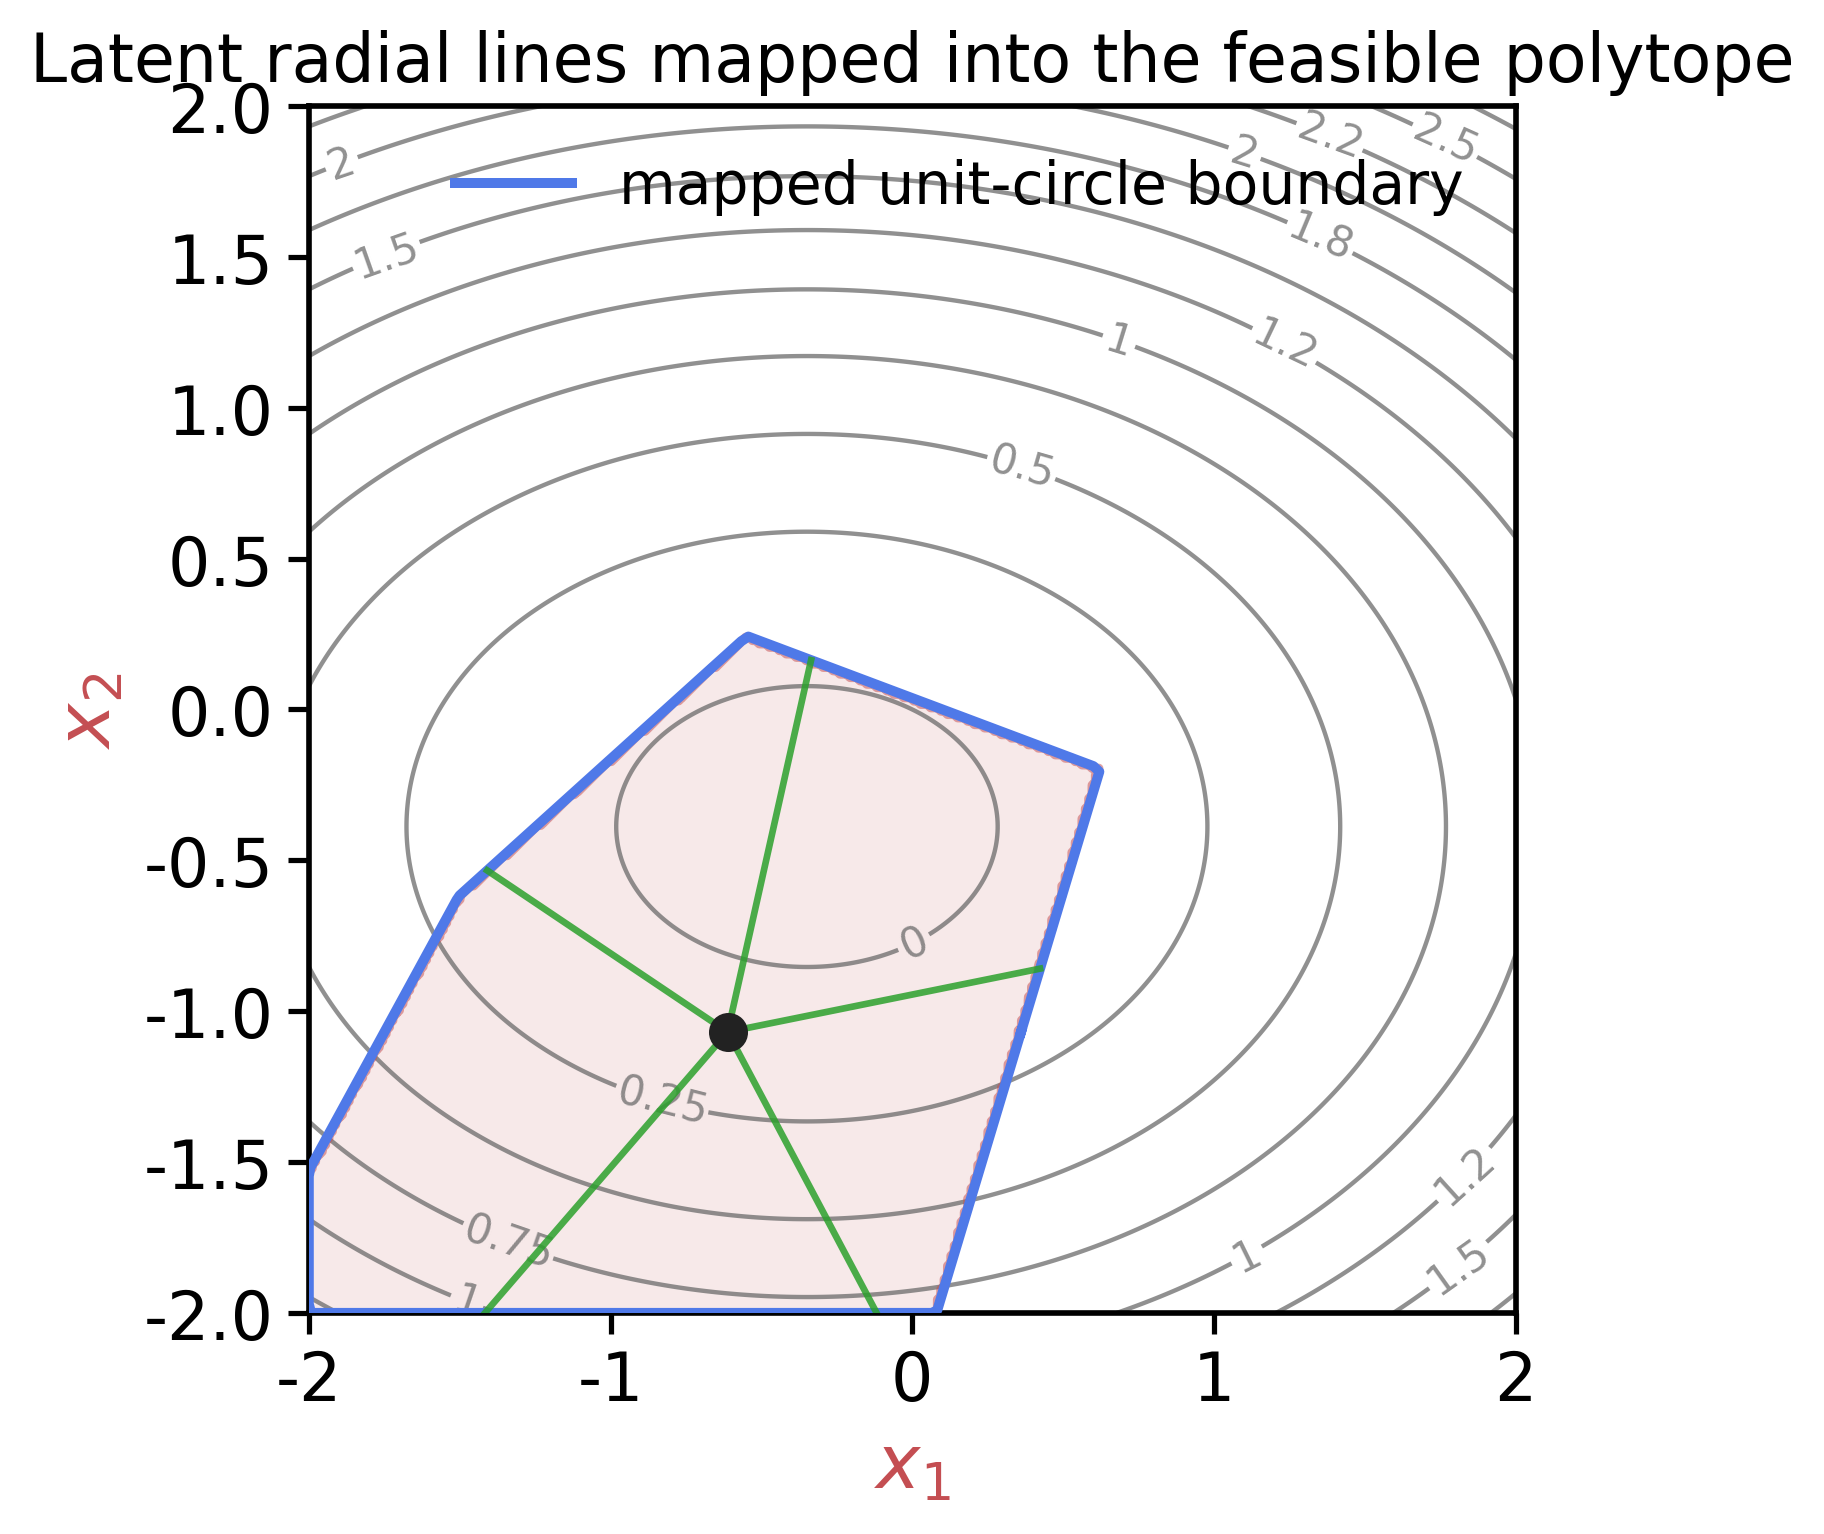

In [14]:
angles = np.linspace(0.0, 2.0 * np.pi, 361)
unit_boundary = np.column_stack([np.cos(angles), np.sin(angles)])
ray_angles = np.array([0.20, 1.35, 2.55, 4.00, 5.20])
radii = np.linspace(0.0, 1.0, 120)

def map_latent(points: np.ndarray) -> np.ndarray:
    z = torch.as_tensor(points, dtype=problem.Q.dtype, device=problem.device)
    with torch.no_grad():
        return hom_map.forward(z, method='autograd').detach().cpu().numpy()

mapped_boundary = map_latent(unit_boundary)
center = hom_map.center.detach().cpu().numpy().reshape(2)

fig, ax = plt.subplots(figsize=TUTORIAL_FIGURE_STYLE['single_panel'], constrained_layout=True)
draw_convex_landscape(ax, X, Y, objective, inequality, equality, eq_resid)
ax.plot(mapped_boundary[:, 0], mapped_boundary[:, 1], color=PAPER_STYLE['z_space_color'], linewidth=2.4, label='mapped unit-circle boundary', zorder=5)
for theta in ray_angles:
    z_ray = np.column_stack([radii * np.cos(theta), radii * np.sin(theta)])
    x_ray = map_latent(z_ray)
    ax.plot(x_ray[:, 0], x_ray[:, 1], color=PAPER_STYLE['trajectory_color'], linewidth=1.6, alpha=0.85, zorder=5)
ax.scatter(*center, s=70, color='#222222', zorder=7)
ax.set_title('Latent radial lines mapped into the feasible polytope')
ax.legend(frameon=False, loc='upper right')

rays_path = save_figure(fig, TUTORIAL_CONFIG['figure_dir'] / 'gauge_mapped_rays.pdf')
rays_path


## 5. Verify the forward/inverse round-trip

The map is parameterized around the interior gauge center. Mapping latent points inside the unit disk forward and then applying `inverse` should recover the original latent coordinates up to floating-point error.

In [15]:
latent_test = np.array([[0.00, 0.00], [0.20, -0.30], [-0.55, 0.35], [0.80, 0.10]], dtype=np.float32)
z_test = torch.as_tensor(latent_test, dtype=problem.Q.dtype, device=problem.device)
with torch.no_grad():
    x_test = hom_map.forward(z_test, method='autograd')
    z_round_trip = hom_map.inverse(x_test, method='autograd')
round_trip_error = torch.max(torch.abs(z_round_trip - z_test)).item()
assert round_trip_error < 1e-5, f'Unexpected round-trip error: {round_trip_error:.3e}'
{'max_round_trip_error': round_trip_error, 'mapped_points': x_test.detach().cpu().numpy()}


{'max_round_trip_error': 8.940696716308594e-08,
 'mapped_points': array([[-0.6119047 , -1.0689194 ],
        [-0.38810074, -1.4046254 ],
        [-1.14321   , -0.730816  ],
        [ 0.2026428 , -0.967101  ]], dtype=float32)}

## Exercises and next steps

1. Change `n_linear_cons` from 5 to 3 or 8 and rerun the geometry panels. How do the mapped radial lines change?
2. Change the seed while keeping the remaining configuration fixed. Verify that the reference solution and gauge center belong to the same sampled instance.
3. Continue with `02_star_hom_pgd_trajectory.ipynb` when available. Unlike this convex case, its reference solution will be computed with IPOPT over multiple starts.

**Pitfall.** Do not replace the explicit convex reference here with a grid search. Grid evaluation is only a visualization technique; it is not the reference-solver path.